Activity        | Train Reps   | Test Reps   
run             | 213          | 54          
squat           | 9            | 3           
step            | 8            | 3           
sts             | 8            | 3           
walk            | 144          | 37          
Classifier Train Accuracy: 1.0000
Classifier Test Accuracy: 0.9971


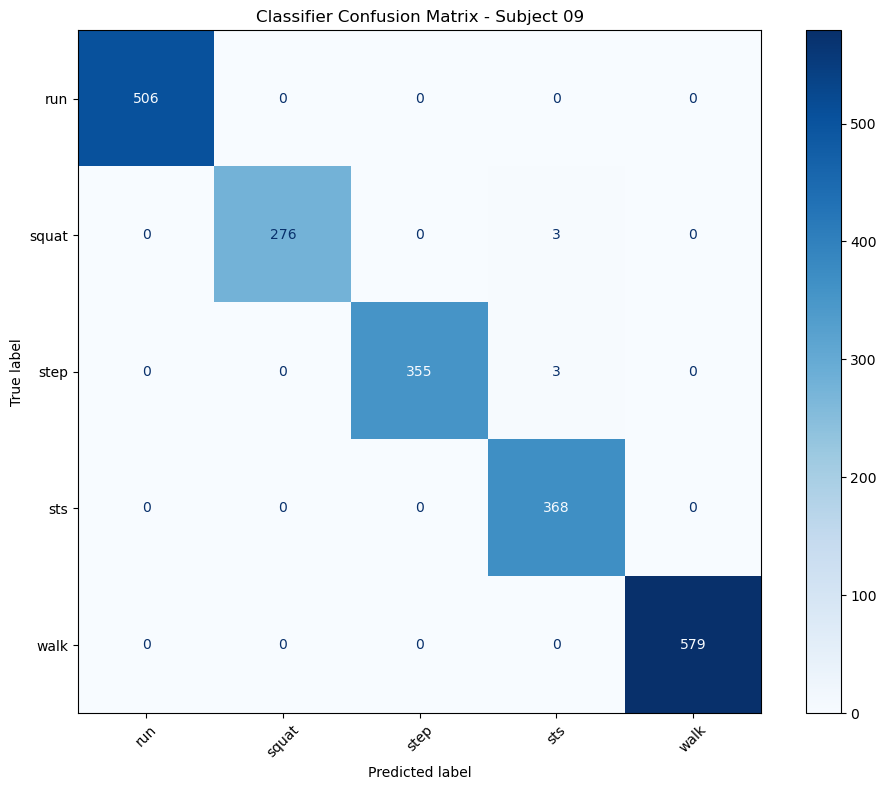

Regressor Train R2: 0.8951, RMSE: 0.8247
Regressor Test R2: 0.7772, RMSE: 2.1050


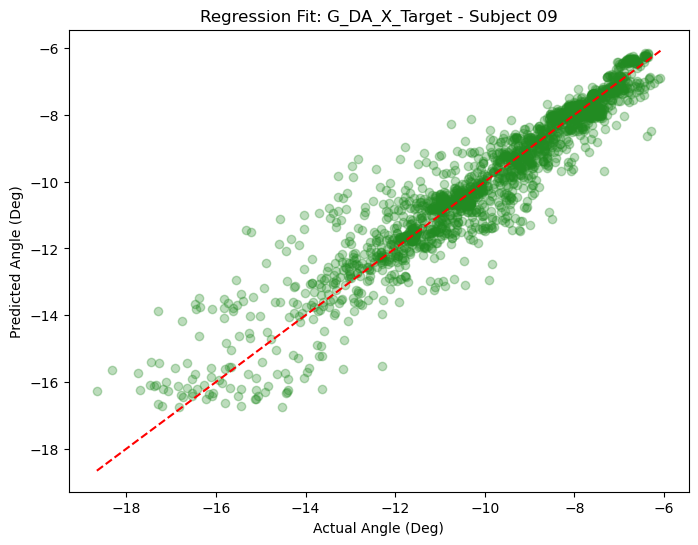

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay

def build_database(subject_id="09", train_ratio=0.8, window_size=410, step_size=102):
    base_dir = Path.cwd()
    data_dir = base_dir.parent / "Data"
    file_path = data_dir / f"{subject_id}_filtered_all_data.pkl"
    
    if not file_path.exists():
        raise FileNotFoundError(f"Could not find data at {file_path}")
        
    df = pd.read_pickle(file_path)
    
    # Filter out activities ending with '_' (weighted variants)
    df = df[~df['Activity'].str.endswith('_')].copy()
    
    ta_cols = [c for c in df.columns if "EMG_TA" in c]
    gm_cols = [c for c in df.columns if "EMG_GM" in c]
    imu_cols = [c for c in df.columns if any(s in c for s in ["-f", "-c", "-q", "-h"])]
    gonio_cols = [c for c in df.columns if c.startswith("G_")]
    
    train_list = []
    test_list = []
    
    # Stratified split by repetitions
    for activity in df['Activity'].unique():
        act_df = df[df['Activity'] == activity]
        reps = act_df['Reps'].unique()
        split_point = int(len(reps) * train_ratio)
        train_list.append(act_df[act_df['Reps'].isin(reps[:split_point])])
        test_list.append(act_df[act_df['Reps'].isin(reps[split_point:])])
    
    datasets = {"train": pd.concat(train_list), "test": pd.concat(test_list)}
    
    # Print repetition distribution
    print(f"{'Activity':<15} | {'Train Reps':<12} | {'Test Reps':<12}")
    for act in sorted(df['Activity'].unique()):
        tr = datasets["train"][datasets["train"]['Activity'] == act]['Reps'].nunique()
        ts = datasets["test"][datasets["test"]['Activity'] == act]['Reps'].nunique()
        print(f"{str(act):<15} | {tr:<12} | {ts:<12}")
    
    results = {}
    for mode, raw_df in datasets.items():
        rows = []
        for start in range(0, len(raw_df) - window_size + 1, step_size):
            end = start + window_size
            window = raw_df.iloc[start:end]
            
            # Ensure window stays within a single repetition and activity
            if window['Activity'].nunique() > 1 or window['Reps'].nunique() > 1:
                continue
                
            last_row = window.iloc[-1]
            feat = {
                "Activity": last_row["Activity"],
                "Gait_Pct": last_row["Gait"]
            }
            # Extract Time Domain features (MAV)
            feat["EMG_TA_MAV"] = np.mean(np.abs(window[ta_cols].to_numpy()))
            feat["EMG_GM_MAV"] = np.mean(np.abs(window[gm_cols].to_numpy()))
            
            # Extract IMU means
            for col in imu_cols:
                feat[f"IMU_{col}_Mean"] = window[col].mean()
            
            # Extract joint angle targets
            for col in gonio_cols:
                feat[f"{col}_Target"] = last_row[col]
            rows.append(feat)
            
        final_df = pd.DataFrame(rows)
        save_path = data_dir / f"{subject_id}_{mode}_features.pkl"
        final_df.to_pickle(save_path)
        results[mode] = final_df

    return results["train"], results["test"]

def train_classifier(train_df, test_df, subject_id="09"):
    # Drop labels and targets to isolate features
    X_train = train_df.drop(columns=['Activity', 'Gait_Pct', *[c for c in train_df.columns if 'Target' in c]])
    y_train = train_df['Activity']
    X_test = test_df.drop(columns=['Activity', 'Gait_Pct', *[c for c in test_df.columns if 'Target' in c]])
    y_test = test_df['Activity']

    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)

    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)

    # Performance metrics
    print(f"Classifier Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"Classifier Test Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=ax, cmap='Blues', xticks_rotation=45)
    ax.set_title(f"Classifier Confusion Matrix - Subject {subject_id}")
    plt.tight_layout()
    plt.show()

    joblib.dump(clf, f"classifier_{subject_id}.pkl")
    return clf

def train_regressor(train_df, test_df, subject_id="09"):
    target_cols = [c for c in train_df.columns if 'Target' in c]
    X_train = train_df.drop(columns=['Activity', 'Gait_Pct', *target_cols])
    y_train = train_df[target_cols]
    X_test = test_df.drop(columns=['Activity', 'Gait_Pct', *target_cols])
    y_test = test_df[target_cols]

    reg = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15,        # Limits how specific the trees can get
    min_samples_leaf=5,   # Ensures each "rule" applies to at least 5 windows
    random_state=42, 
    n_jobs=-1
    )
    
    reg.fit(X_train, y_train)

    # Evaluate Training Performance
    y_pred_tr = reg.predict(X_train)
    r2_tr = r2_score(y_train, y_pred_tr)
    rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_tr))

    # Evaluate Testing Performance
    y_pred_ts = reg.predict(X_test)
    r2_ts = r2_score(y_test, y_pred_ts)
    rmse_ts = np.sqrt(mean_squared_error(y_test, y_pred_ts))

    print(f"Regressor Train R2: {r2_tr:.4f}, RMSE: {rmse_tr:.4f}")
    print(f"Regressor Test R2: {r2_ts:.4f}, RMSE: {rmse_ts:.4f}")

    # Plot actual vs predicted for the first joint target
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test.iloc[:, 0], y_pred_ts[:, 0], alpha=0.3, color='forestgreen')
    plt.plot([y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()], 
             [y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()], 'r--')
    plt.xlabel('Actual Angle (Deg)')
    plt.ylabel('Predicted Angle (Deg)')
    plt.title(f"Regression Fit: {y_test.columns[0]} - Subject {subject_id}")
    plt.show()

    joblib.dump(reg, f"regressor_{subject_id}.pkl")
    return reg

# Run pipeline
train_db, test_db = build_database()
classifier_model = train_classifier(train_db, test_db)
regressor_model = train_regressor(train_db, test_db)